# Modélisation de la Consommation Énergétique des Bâtiments de Seattle

---

## Contexte du Projet

**Objectif** : Prédire la consommation énergétique (`SiteEnergyUse(kBtu)`) des bâtiments non résidentiels de Seattle pour aider la ville à atteindre son objectif de **neutralité carbone en 2050**.

**Données** : Relevés de consommation énergétique des bâtiments de Seattle en 2016

**Méthodologie** :
1. Préparation des données (suppression du data leakage)
2. Analyse des features importantes
3. Sélection des features pertinentes
4. Comparaison de plusieurs algorithmes de régression
5. Évaluation et recommandation

---

## 1. Imports et Configuration

In [1]:
pip install pandas numpy matplotlib scikit-learn category_encoders

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder

# Métriques
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Utilitaires
import time
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des Données

In [3]:
# Charger les données nettoyées
df_clean = pd.read_pickle('df_clean.pkl')

print("✅ Dataset chargé avec succès")
print(f"📊 Dimensions : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"\n📋 Colonnes disponibles :")
print(df_clean.columns.tolist())

✅ Dataset chargé avec succès
📊 Dimensions : 1624 lignes × 35 colonnes

📋 Colonnes disponibles :
['DataYear', 'BuildingType', 'PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'DefaultData', 'ComplianceStatus', 'TotalGHGEmissions', 'GHGEmissionsIntensity']


In [4]:
# Aperçu rapide des données
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1624 entries, 0 to 3375
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1624 non-null   int64  
 1   BuildingType                     1624 non-null   object 
 2   PrimaryPropertyType              1624 non-null   object 
 3   CouncilDistrictCode              1624 non-null   int64  
 4   Neighborhood                     1624 non-null   object 
 5   Latitude                         1624 non-null   float64
 6   Longitude                        1624 non-null   float64
 7   YearBuilt                        1624 non-null   int64  
 8   NumberofBuildings                1622 non-null   float64
 9   NumberofFloors                   1624 non-null   int64  
 10  PropertyGFATotal                 1624 non-null   int64  
 11  PropertyGFAParking               1624 non-null   int64  
 12  PropertyGFABuilding(s)   

## 3. Feature Engineering : création de variables binaires

In [5]:
# ÉTAT INITIAL
print(f"\n📊 ÉTAT INITIAL :")
print(f"   Nombre de lignes : {len(df_clean)}")
print(f"   Nombre de colonnes : {df_clean.shape[1]}")

print("\n2️⃣ TRAITEMENT : Usages secondaires et tertiaires")
print("-"*80)

# Remplir les valeurs manquantes
df_clean['SecondLargestPropertyUseType'] = df_clean['SecondLargestPropertyUseType'].fillna('None')
df_clean['SecondLargestPropertyUseTypeGFA'] = df_clean['SecondLargestPropertyUseTypeGFA'].fillna(0)
df_clean['ThirdLargestPropertyUseType'] = df_clean['ThirdLargestPropertyUseType'].fillna('None')
df_clean['ThirdLargestPropertyUseTypeGFA'] = df_clean['ThirdLargestPropertyUseTypeGFA'].fillna(0)
df_clean['LargestPropertyUseTypeGFA'] = df_clean['LargestPropertyUseTypeGFA'].fillna(0)

print("✅ Rempli les valeurs manquantes de SecondLargestPropertyUseType par 'None'")
print("✅ Rempli les valeurs manquantes de SecondLargestPropertyUseTypeGFA par 0")
print("✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseType par 'None'")
print("✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseTypeGFA par 0")


📊 ÉTAT INITIAL :
   Nombre de lignes : 1624
   Nombre de colonnes : 35

2️⃣ TRAITEMENT : Usages secondaires et tertiaires
--------------------------------------------------------------------------------
✅ Rempli les valeurs manquantes de SecondLargestPropertyUseType par 'None'
✅ Rempli les valeurs manquantes de SecondLargestPropertyUseTypeGFA par 0
✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseType par 'None'
✅ Rempli les valeurs manquantes de ThirdLargestPropertyUseTypeGFA par 0


In [6]:
print("\n3️⃣ TRAITEMENT : Certification ENERGY STAR")
print("-"*80)

#  Remplir YearsENERGYSTARCertified manquant par None
df_clean['YearsENERGYSTARCertified'] = df_clean['YearsENERGYSTARCertified'].fillna('None')

# Remplir ENERGYSTARScore manquant par 0 
df_clean['ENERGYSTARScore'] = df_clean['ENERGYSTARScore'].fillna(0)

print("✅ Rempli les valeurs manquantes de YearsENERGYSTARCertified None")
print("✅ Rempli les valeurs manquantes de ENERGYSTARScore par 0")


3️⃣ TRAITEMENT : Certification ENERGY STAR
--------------------------------------------------------------------------------
✅ Rempli les valeurs manquantes de YearsENERGYSTARCertified None
✅ Rempli les valeurs manquantes de ENERGYSTARScore par 0


In [7]:
print("\n4️⃣ TRAITEMENT : Sources d'énergie")
print("-"*80)

df_clean['SteamUse(kBtu)'] = df_clean['SteamUse(kBtu)'].fillna(0)
df_clean['NaturalGas(kBtu)'] = df_clean['NaturalGas(kBtu)'].fillna(0)
df_clean['Electricity(kBtu)'] = df_clean['Electricity(kBtu)'].fillna(0)

print(f"   ✅ Rempli les valeurs manquantes de SteamUse(kBtu) par 0")
print(f"   ✅ Rempli les valeurs manquantes de NaturalGas(kBtu) par 0")
print(f"   ✅ Rempli les valeurs manquantes de Electricity(kBtu) par 0")




4️⃣ TRAITEMENT : Sources d'énergie
--------------------------------------------------------------------------------
   ✅ Rempli les valeurs manquantes de SteamUse(kBtu) par 0
   ✅ Rempli les valeurs manquantes de NaturalGas(kBtu) par 0
   ✅ Rempli les valeurs manquantes de Electricity(kBtu) par 0


In [8]:
print("\n5️⃣ TRAITEMENT : Variable cible (CRITIQUE)")
print("-"*80)

lignes_avant = len(df_clean)
df_clean = df_clean.dropna(subset=['SiteEnergyUse(kBtu)'])
lignes_apres = len(df_clean)

print(f"   ✅ Supprimé {lignes_avant - lignes_apres} lignes sans valeur cible")
print(f"   📊 Lignes restantes : {lignes_apres}")


5️⃣ TRAITEMENT : Variable cible (CRITIQUE)
--------------------------------------------------------------------------------
   ✅ Supprimé 2 lignes sans valeur cible
   📊 Lignes restantes : 1622


In [9]:
print("\n6️⃣ TRAITEMENT : Autres colonnes")
print("-"*80)

# LargestPropertyUseType (0.4% manquant) - Remplir les valeurs manquantes de LargestPropertyUseType par PrimaryPropertyType
df_clean['LargestPropertyUseType'] = df_clean['LargestPropertyUseType'].fillna(df_clean['PrimaryPropertyType'])
print("✅ Rempli LargestPropertyUseType avec PrimaryPropertyType")

## NumberofBuildings (0.1% manquant)
if df_clean['NumberofBuildings'].isnull().sum() > 0:
    median_buildings = df_clean['NumberofBuildings'].median()
    df_clean['NumberofBuildings'] = df_clean['NumberofBuildings'].fillna(median_buildings)
    print(f"   ✅ Rempli NumberofBuildings par la médiane ({median_buildings})")

# ListOfAllPropertyUseTypes (0.1% manquant)
if df_clean['ListOfAllPropertyUseTypes'].isnull().sum() > 0:
    lignes_avant = len(df_clean)
    df_clean = df_clean.dropna(subset=['ListOfAllPropertyUseTypes'])
    print(f"   ✅ Supprimé {lignes_avant - len(df_clean)} lignes sans ListOfAllPropertyUseTypes")

# Toutes les autres petites valeurs manquantes
autres_colonnes = ['SiteEnergyUseWN(kBtu)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
                   'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
                   'TotalGHGEmissions', 'GHGEmissionsIntensity']

lignes_avant = len(df_clean)
df_clean = df_clean.dropna(subset=autres_colonnes)
print(f"   ✅ Supprimé {lignes_avant - len(df_clean)} lignes avec autres valeurs manquantes")


6️⃣ TRAITEMENT : Autres colonnes
--------------------------------------------------------------------------------
✅ Rempli LargestPropertyUseType avec PrimaryPropertyType
   ✅ Supprimé 2 lignes avec autres valeurs manquantes


In [10]:
print("\n📊 ÉTAT FINAL :")
print("-"*80)
print(f"   Nombre de lignes : {len(df_clean)}")
print(f"   Nombre de colonnes : {df_clean.shape[1]}")
print(f"   Lignes supprimées au total : {1668 - len(df_clean)}")

# Vérifier s'il reste des valeurs manquantes
valeurs_manquantes_restantes = df_clean.isnull().sum().sum()
print(f"\n   Valeurs manquantes restantes : {valeurs_manquantes_restantes}")

if valeurs_manquantes_restantes == 0:
    print("\n   ✅✅✅ AUCUNE VALEUR MANQUANTE ! Dataset propre ! ✅✅✅")
else:
    print(f"\n   ⚠️ Il reste encore {valeurs_manquantes_restantes} valeurs manquantes")
    print("\n   Colonnes avec valeurs manquantes :")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


📊 ÉTAT FINAL :
--------------------------------------------------------------------------------
   Nombre de lignes : 1620
   Nombre de colonnes : 35
   Lignes supprimées au total : 48

   Valeurs manquantes restantes : 0

   ✅✅✅ AUCUNE VALEUR MANQUANTE ! Dataset propre ! ✅✅✅


#### a) Création de la variable age_batiment

In [11]:
df_clean['building_age'] = df_clean['DataYear'] - df_clean['YearBuilt']

In [12]:
print(df_clean['building_age'].unique())

[ 89  20  47  90  36  17 112  18  88  94  12  86  33 109 100  31  55  15
  25  61  38  67  27 110  22  24  26  66 116  62 105  43  96 106  34 108
  57  16  19  54  46   8  68  51  87   6  78  30  14  93  13  59  52  75
  53  10 101  58   7   5  45   9  65  64  56  79  50  48  91  92  11  85
  44 102 103  35  40 107  28  37  69  32  60 104  39  95  71  42  41  70
  21  49  29  76  63  84  23  98 111 114  77  72  99  74 113   4   3  97
 115  80  81   2   1]


## 4. Encodage des variables catégorielles

In [13]:
print("📊 INVENTAIRE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Identifier les colonnes de type 'object' (texte)
colonnes_categorielles = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f"\n✅ Nombre de variables catégorielles : {len(colonnes_categorielles)}\n")

# Analyser chaque variable catégorielle
for col in colonnes_categorielles:
    n_categories = df_clean[col].nunique()
    print(f"📌 {col}")
    print(f"   Nombre de catégories : {n_categories}")
    print(f"   Valeurs : {df_clean[col].value_counts().head(5).to_dict()}")
    print()

print("="*80)

📊 INVENTAIRE DES VARIABLES CATÉGORIELLES

✅ Nombre de variables catégorielles : 9

📌 BuildingType
   Nombre de catégories : 5
   Valeurs : {'NonResidential': 1428, 'SPS-District K-12': 97, 'Nonresidential COS': 82, 'Campus': 12, 'Nonresidential WA': 1}

📌 PrimaryPropertyType
   Nombre de catégories : 22
   Valeurs : {'Small- and Mid-Sized Office': 287, 'Other': 236, 'Warehouse': 187, 'Large Office': 168, 'K-12 School': 135}

📌 Neighborhood
   Nombre de catégories : 19
   Valeurs : {'DOWNTOWN': 351, 'GREATER DUWAMISH': 337, 'LAKE UNION': 147, 'MAGNOLIA / QUEEN ANNE': 147, 'NORTHEAST': 121}

📌 ListOfAllPropertyUseTypes
   Nombre de catégories : 366
   Valeurs : {'Office': 135, 'K-12 School': 131, 'Office, Parking': 119, 'Non-Refrigerated Warehouse': 101, 'Non-Refrigerated Warehouse, Office': 61}

📌 LargestPropertyUseType
   Nombre de catégories : 56
   Valeurs : {'Office': 487, 'Non-Refrigerated Warehouse': 199, 'K-12 School': 135, 'Retail Store': 97, 'Other': 90}

📌 SecondLargestPropert

In [14]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_cols = ['BuildingType', 'ComplianceStatus']

ohe_encoded = ohe.fit_transform(df_clean[ohe_cols])

ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df_clean.index
)

binary_cols = [
    'PrimaryPropertyType',
    'Neighborhood',
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType',
    'ThirdLargestPropertyUseType'
]

binary_encoder = BinaryEncoder(cols=binary_cols)

binary_df = binary_encoder.fit_transform(df_clean[binary_cols])

df_clean = df_clean.drop(
    columns=ohe_cols + binary_cols + ['ListOfAllPropertyUseTypes']
)

df_clean = pd.concat(
    [df_clean, ohe_df, binary_df],
    axis=1
)

## 5. Features supplémentaires : RATIOS ET PROPORTIONS
création de 4 ratios :
- **parking_ratio** surfaceparking/surface total
- **main_use_ratio** type d'utilisation/surface total
- **energie_ratio** ratio type energie

In [15]:
# 1. RATIOS surfaceparking/surface total et type d'utilisation/surface total
df_clean['parking_ratio'] = df_clean['PropertyGFAParking'] / df_clean['PropertyGFATotal']
df_clean['main_use_ratio'] = df_clean['LargestPropertyUseTypeGFA'] / df_clean['PropertyGFATotal']
df_clean['energie_total'] = (df_clean['NaturalGas(kBtu)']+ df_clean['Electricity(kBtu)']+df_clean['SteamUse(kBtu)']) / 3
df_clean['energie_ratio'] = df_clean['energie_total'] / df_clean['PropertyGFATotal']
df_clean['second_use_ratio'] = df_clean['SecondLargestPropertyUseTypeGFA'] / df_clean['PropertyGFATotal']
df_clean['third_use_ratio'] = df_clean['ThirdLargestPropertyUseTypeGFA'] / df_clean['PropertyGFATotal']
df_clean['usable_area'] = df_clean['PropertyGFATotal'] - df_clean['PropertyGFAParking']

# Gérer les divisions par zéro (si PropertyGFATotal = 0)
df_clean['parking_ratio'] = df_clean['parking_ratio'].fillna(0)
df_clean['main_use_ratio'] = df_clean['main_use_ratio'].fillna(0)

In [16]:
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )
print(df_clean.info())

Le nouveau dataset est composé de 1620 lignes et de 71 colonnes
<class 'pandas.core.frame.DataFrame'>
Index: 1620 entries, 0 to 3375
Data columns (total 71 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   DataYear                                       1620 non-null   int64  
 1   CouncilDistrictCode                            1620 non-null   int64  
 2   Latitude                                       1620 non-null   float64
 3   Longitude                                      1620 non-null   float64
 4   YearBuilt                                      1620 non-null   int64  
 5   NumberofBuildings                              1620 non-null   float64
 6   NumberofFloors                                 1620 non-null   int64  
 7   PropertyGFATotal                               1620 non-null   int64  
 8   PropertyGFAParking                             1620 non-null   int64 

**Analyse**  
Il y a une corrélation entre la surface et la consommation.
Il n'y a pas très peu de corrélation entre l'année de constructions et la consommations 

Décision d'encodage pour chaque variable :

    OneHotEncoder : BuildingType ; ComplianceStatus / car peu de catégories
    BinaryEncoder : PrimaryPropertyType ; Neighborhood ; LargestPropertyUseType ; SecondLargestPropertyUseType; ThirdLargestPropertyUseType
    pour ListOfAllPropertyUseTypes, il y a trop de catégorie (371) donc on ne l'utilisera pas.



In [17]:
print(f"Après la suppression des Outlier. Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )

Après la suppression des Outlier. Le nouveau dataset est composé de 1620 lignes et de 71 colonnes


## 7. Analyse des Features Importantes

**Objectif** : Identifier les features les plus prédictives pour simplifier le modèle.

**Méthodologie** : Utiliser l'importance des features du Random Forest comme indicateur.


✅ Matrice calculée pour 37 variables UTILISABLES


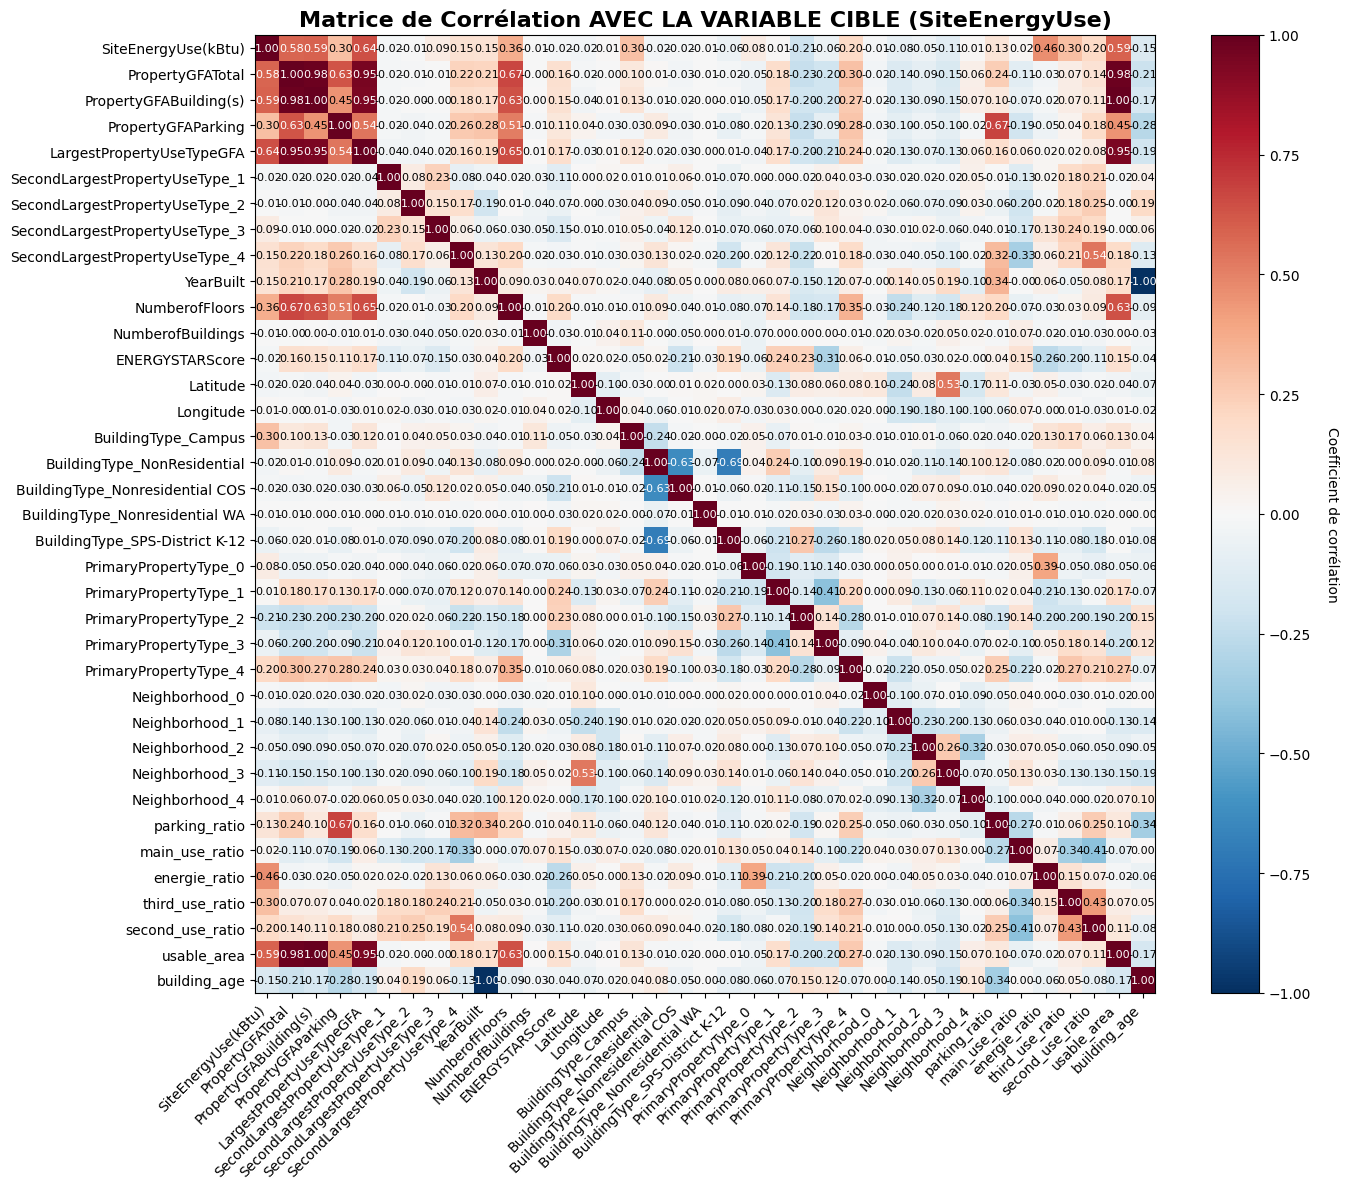



🎯 CORRÉLATIONS AVEC LA VARIABLE CIBLE (SiteEnergyUse)
   Variables structurelles UNIQUEMENT - utilisables pour la prédiction
--------------------------------------------------------------------------------

📈 Top TOUTES les corrélations (ordre décroissant) :
    1. LargestPropertyUseTypeGFA                : +0.642  [MOYENNE   ]
    2. usable_area                              : +0.587  [MOYENNE   ]
    3. PropertyGFABuilding(s)                   : +0.587  [MOYENNE   ]
    4. PropertyGFATotal                         : +0.582  [MOYENNE   ]
    5. energie_ratio                            : +0.465  [MOYENNE   ]
    6. NumberofFloors                           : +0.364  [FAIBLE    ]
    7. third_use_ratio                          : +0.298  [FAIBLE    ]
    8. PropertyGFAParking                       : +0.297  [FAIBLE    ]
    9. BuildingType_Campus                      : +0.296  [FAIBLE    ]
   10. PrimaryPropertyType_4                    : +0.203  [FAIBLE    ]
   11. second_use_ratio      

In [18]:
colonnes_importantes = [
    'SiteEnergyUse(kBtu)',           # Variable cible
    'PropertyGFATotal',              # Surface totale
    'PropertyGFABuilding(s)',        # Surface bâtiment
    'PropertyGFAParking',            # Surface parking
    'LargestPropertyUseTypeGFA',     # Surface usage principal
    'SecondLargestPropertyUseType_1',
    'SecondLargestPropertyUseType_2', 
    'SecondLargestPropertyUseType_3',
    'SecondLargestPropertyUseType_4',
    'YearBuilt',                     # Année construction
    'NumberofFloors',                # Nombre d'étages
    'NumberofBuildings',             # Nombre de bâtiments
    'ENERGYSTARScore',               # Score certification
    'Latitude',                      # Position géographique
    'Longitude',                      # Position géographique
    'BuildingType_Campus',                            
    'BuildingType_NonResidential',                   
    'BuildingType_Nonresidential COS',                
    'BuildingType_Nonresidential WA',                 
    'BuildingType_SPS-District K-12', 
    'PrimaryPropertyType_0',
    'PrimaryPropertyType_1',
    'PrimaryPropertyType_2',
    'PrimaryPropertyType_3',
    'PrimaryPropertyType_4',
    'Neighborhood_0',
    'Neighborhood_1', 
    'Neighborhood_2', 
    'Neighborhood_3', 
    'Neighborhood_4', 
    'parking_ratio',                   #nouvelle variables
    'main_use_ratio',
    'energie_ratio',                 
    'third_use_ratio',
    'second_use_ratio',
    'usable_area', 
    'building_age'
]

# Créer un sous-dataframe avec ces colonnes
df_colonne = df_clean[colonnes_importantes].copy()

# Calculer la matrice de corrélation
correlation_matrix = df_colonne.corr()

print(f"\n✅ Matrice calculée pour {len(colonnes_importantes)} variables UTILISABLES")

# Créer la visualisation
fig, ax = plt.subplots(figsize=(14, 12))

# Créer la heatmap
im = ax.imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Ajouter les labels
ax.set_xticks(np.arange(len(colonnes_importantes)))
ax.set_yticks(np.arange(len(colonnes_importantes)))
ax.set_xticklabels(colonnes_importantes, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(colonnes_importantes, fontsize=10)

# Ajouter les valeurs dans chaque case
for i in range(len(colonnes_importantes)):
    for j in range(len(colonnes_importantes)):
        value = correlation_matrix.iloc[i, j]
        text_color = 'white' if abs(value) > 0.5 else 'black'
        text = ax.text(j, i, f'{value:.2f}', 
                      ha="center", va="center", color=text_color, fontsize=8)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coefficient de corrélation', rotation=270, labelpad=20)

# Titre
ax.set_title('Matrice de Corrélation AVEC LA VARIABLE CIBLE (SiteEnergyUse)', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)

# Analyser les corrélations avec la variable cible
print("\n🎯 CORRÉLATIONS AVEC LA VARIABLE CIBLE (SiteEnergyUse)")
print("   Variables structurelles UNIQUEMENT - utilisables pour la prédiction")
print("-"*80)

target_correlations = correlation_matrix['SiteEnergyUse(kBtu)'].drop('SiteEnergyUse(kBtu)').sort_values(ascending=False)

print("\n📈 Top TOUTES les corrélations (ordre décroissant) :")
for i, (var, corr) in enumerate(target_correlations.items(), 1):
    # Interpréter la force
    if abs(corr) > 0.7:
        force = "FORTE     "
    elif abs(corr) > 0.4:
        force = "MOYENNE   "
    else:
        force = "FAIBLE    "
    
    print(f"   {i:2d}. {var:40s} : {corr:+.3f}  [{force}]")

print("="*80)

## 6. Préparation des Données

### 3.1 Suppression des colonnes pour éviter le Data Leakage

**Colonnes à supprimer** :
- Variables calculées à partir de la target (EUI, etc.)
- Composantes de la consommation (Electricity, Gas, Steam)
- Émissions de GES (liées directement à la consommation)

In [19]:
# Colonnes à supprimer pour éviter le data leakage
colonnes_a_supprimer = [
    # Variables calculées à partir de la target
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)',
    
    # Composantes de la consommation (= data leakage direct)
    'Electricity(kBtu)',
    'NaturalGas(kBtu)',
    'SteamUse(kBtu)',
    
    # Émissions (liées directement à la consommation)
    'TotalGHGEmissions',
    'GHGEmissionsIntensity',
]

# Créer le dataset pour la modélisation
df_model = df_clean.drop(columns=colonnes_a_supprimer)

print(f"✅ Colonnes supprimées : {len(colonnes_a_supprimer)}")
print(f"📊 Nouvelles dimensions : {df_model.shape}")

✅ Colonnes supprimées : 10
📊 Nouvelles dimensions : (1620, 61)


### 3.2 Séparation Features (X) et Target (y)

In [20]:
# Séparer features et target
X = df_model.drop(columns=['SiteEnergyUse(kBtu)'])
y = df_model['SiteEnergyUse(kBtu)']

print("✅ Séparation effectuée")
print(f"📊 X (features) : {X.shape}")
print(f"🎯 y (target) : {y.shape}")
print(f"\n📋 Features disponibles ({X.shape[1]}) :")
print(X.columns.tolist())

✅ Séparation effectuée
📊 X (features) : (1620, 60)
🎯 y (target) : (1620,)

📋 Features disponibles (60) :
['DataYear', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'DefaultData', 'building_age', 'BuildingType_Campus', 'BuildingType_NonResidential', 'BuildingType_Nonresidential COS', 'BuildingType_Nonresidential WA', 'BuildingType_SPS-District K-12', 'ComplianceStatus_Compliant', 'ComplianceStatus_Error - Correct Default Data', 'ComplianceStatus_Missing Data', 'PrimaryPropertyType_0', 'PrimaryPropertyType_1', 'PrimaryPropertyType_2', 'PrimaryPropertyType_3', 'PrimaryPropertyType_4', 'Neighborhood_0', 'Neighborhood_1', 'Neighborhood_2', 'Neighborhood_3', 'Neighborhood_4', 'LargestPropertyUseType_0', 'LargestPropertyUseType_1'

## 8. Sélection des Features

In [21]:
# Sélection des 5 features principales
features_selectionnees = [
    'PropertyGFATotal',              # Surface totale
    'PropertyGFABuilding(s)',        # Surface bâtiment
    'PropertyGFAParking',            # Surface parking
    'LargestPropertyUseTypeGFA',     # Surface usage principal
    'SecondLargestPropertyUseTypeGFA', # Surface usage secondaire
    'ThirdLargestPropertyUseTypeGFA',  # Surface usage tertiaire
    'SecondLargestPropertyUseType_1',
    'SecondLargestPropertyUseType_2', 
    'SecondLargestPropertyUseType_3',
    'SecondLargestPropertyUseType_4',
    'NumberofFloors',                # Nombre d'étages
    'NumberofBuildings',             # Nombre de bâtiments
    'ENERGYSTARScore',               # Score certification
    'Latitude',                      # Position géographique
    'Longitude',                      # Position géographique
    'BuildingType_Campus',                            
    'BuildingType_NonResidential',                   
    'BuildingType_Nonresidential COS',                
    'BuildingType_Nonresidential WA',                 
    'BuildingType_SPS-District K-12', 
    'PrimaryPropertyType_0',
    'PrimaryPropertyType_1',
    'PrimaryPropertyType_2',
    'PrimaryPropertyType_3',
    'PrimaryPropertyType_4',
    'Neighborhood_0',
    'Neighborhood_1', 
    'Neighborhood_2', 
    'Neighborhood_3', 
    'Neighborhood_4', 
    'parking_ratio',                   #nouvelle variables
    'main_use_ratio',
    'energie_ratio',                 
    'third_use_ratio',
    'second_use_ratio',
    'usable_area', 
    'building_age'
]

# Créer le nouveau dataset simplifié
X_simple = df_model[features_selectionnees]
y_simple = df_model['SiteEnergyUse(kBtu)']

print("✅ Sélection effectuée")
print(f"📊 Nouvelles dimensions : {X_simple.shape}")
print(f"\n📋 Features sélectionnées :")
for i, feat in enumerate(features_selectionnees, 1):
    print(f"  {i}. {feat}")

✅ Sélection effectuée
📊 Nouvelles dimensions : (1620, 37)

📋 Features sélectionnées :
  1. PropertyGFATotal
  2. PropertyGFABuilding(s)
  3. PropertyGFAParking
  4. LargestPropertyUseTypeGFA
  5. SecondLargestPropertyUseTypeGFA
  6. ThirdLargestPropertyUseTypeGFA
  7. SecondLargestPropertyUseType_1
  8. SecondLargestPropertyUseType_2
  9. SecondLargestPropertyUseType_3
  10. SecondLargestPropertyUseType_4
  11. NumberofFloors
  12. NumberofBuildings
  13. ENERGYSTARScore
  14. Latitude
  15. Longitude
  16. BuildingType_Campus
  17. BuildingType_NonResidential
  18. BuildingType_Nonresidential COS
  19. BuildingType_Nonresidential WA
  20. BuildingType_SPS-District K-12
  21. PrimaryPropertyType_0
  22. PrimaryPropertyType_1
  23. PrimaryPropertyType_2
  24. PrimaryPropertyType_3
  25. PrimaryPropertyType_4
  26. Neighborhood_0
  27. Neighborhood_1
  28. Neighborhood_2
  29. Neighborhood_3
  30. Neighborhood_4
  31. parking_ratio
  32. main_use_ratio
  33. energie_ratio
  34. third_use

In [22]:
# Split Train/Test pour le modèle simplifié
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, 
    y_simple, 
    test_size=0.2, 
    random_state=42
)

print("✅ Split effectué")
print(f"📊 Ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"📊 Ensemble de test : {X_test.shape[0]} lignes")

✅ Split effectué
📊 Ensemble d'entraînement : 1296 lignes
📊 Ensemble de test : 324 lignes


In [23]:
# Séparer colonnes numériques et catégorielles pour le diagnostic
num_cols_check = X_train.select_dtypes(include=[np.number]).columns
cat_cols_check = X_train.select_dtypes(exclude=[np.number]).columns

print("🔍 Diagnostic des données d'entraînement:")
print(f"\nColonnes numériques: {len(num_cols_check)}")
print(f"Colonnes catégorielles: {len(cat_cols_check)}")

# Vérifier les valeurs infinies et NaN dans les colonnes numériques
print(f"\n📊 Sur les colonnes numériques:")
print(f"Nombre de valeurs infinies: {np.isinf(X_train[num_cols_check]).sum().sum()}")
print(f"Nombre de valeurs NaN: {X_train[num_cols_check].isna().sum().sum()}")

if np.isinf(X_train[num_cols_check]).sum().sum() > 0:
    print("\n⚠️ Colonnes contenant des valeurs infinies:")
    inf_cols = X_train[num_cols_check].columns[np.isinf(X_train[num_cols_check]).any()].tolist()
    print(inf_cols)

🔍 Diagnostic des données d'entraînement:

Colonnes numériques: 37
Colonnes catégorielles: 0

📊 Sur les colonnes numériques:
Nombre de valeurs infinies: 0
Nombre de valeurs NaN: 0


## 9. Modélisation et Comparaison d'Algorithmes

**Approche méthodologique** : Tester plusieurs algorithmes du plus simple au plus complexe.

**Algorithmes testés** :
1. **Dummy Regressor** (baseline) - Prédit toujours la moyenne
2. **Linear Regression** - Relation linéaire simple
3. **SVR** (Support Vector Regression) - Relation non-linéaire
4. **Random Forest** - Ensemble d'arbres de décision

**Métriques d'évaluation** :
- **R²** : Coefficient de détermination (0 à 1, plus c'est élevé, mieux c'est)
- **RMSE** : Erreur quadratique moyenne (en kBtu)
- **MAE** : Erreur absolue moyenne (en kBtu)
- **MAPE** : Erreur absolue moyenne en pourcentage

In [24]:
modeles = {
    'Dummy (Baseline)': Pipeline([
        ('model', DummyRegressor(strategy='mean'))
    ]),

    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVR(kernel='rbf', C=1.0))
    ]),

    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=15,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42
        ))
])
}

resultats = []

for nom, pipeline in modeles.items():
    print(f"\n🔧 Entraînement : {nom}")
    
    # Mesurer le temps d'entraînement
    start_time = time.time()
    
    # Entraîner le modèle
    pipeline.fit(X_train, y_train)
    
    # Temps d'entraînement
    train_time = round(time.time() - start_time,4)
    
    # Prédictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
   # Calcul des métriques pour TRAIN
    r2_train = round(r2_score(y_train, y_pred_train),4)
    mae_train = round(mean_absolute_error(y_train, y_pred_train),1)
    mse_train = round(mean_squared_error(y_train, y_pred_train),1)  
    rmse_train = round(np.sqrt(mse_train),1) 

    # Calcul des métriques pour TEST
    r2_test = round(r2_score(y_test, y_pred_test),2)
    ecart_R2 = round(r2_train - r2_test,4)
    mae_test = round(mean_absolute_error(y_test, y_pred_test),2)
    mse_test = round(mean_squared_error(y_test, y_pred_test),2)  
    rmse_test = round(np.sqrt(mse_test),2) 
    
    # MAPE (en évitant les divisions par zéro)
    mask = y_test != 0
    mape = round(np.mean(np.abs((y_test[mask] - y_pred_test[mask]) / y_test[mask])) * 100,1)
    
    # Stocker les résultats
    resultats.append({
        'Modèle': nom,
        'Temps (s)': train_time,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'Ecart R²' : ecart_R2,
        'MAE Train': mae_train,
        'MAE Test': mae_test,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'MAPE (%)': mape
    })
    
   
    # Création d'un tableau comparatif
    resultats_df = pd.DataFrame(resultats).sort_values('R² Test', ascending=False)

print("\n📊 TABLEAU COMPARATIF DES MODÈLES")
print("="*100)
print(resultats_df.to_string(index=False))
print("="*100)
  
print("\n✅ ENTRAÎNEMENT TERMINÉ !")


🔧 Entraînement : Dummy (Baseline)

🔧 Entraînement : Linear Regression

🔧 Entraînement : SVR

🔧 Entraînement : Random Forest

📊 TABLEAU COMPARATIF DES MODÈLES
           Modèle  Temps (s)  R² Train  R² Test  Ecart R²  MAE Train   MAE Test  RMSE Train   RMSE Test  MAPE (%)
    Random Forest     1.8435    0.5894     0.78   -0.1906  1455914.9 1235857.24  11077790.2  5571113.98      13.2
Linear Regression     0.0515    0.8367     0.62    0.2167  3283434.9 3458310.45   6985756.1  7429573.96     103.7
 Dummy (Baseline)     0.0029    0.0000    -0.00    0.0000  7236093.2 6665839.00  17288533.6 11981915.58     340.6
              SVR     0.3830   -0.0693    -0.14    0.0707  5756451.2 5548253.64  17877221.1 12784548.60     110.2

✅ ENTRAÎNEMENT TERMINÉ !


**analyse**
Le résultat de la MAPE (Mean Absolute Pourcentage Error/la moyenne en % des erreurs) est très élevé pour certains modèles. Cela peut s'expliquer par les valeurs extrèmes de notre dataset. Je ne la prendrai donc pas en compte, car nous avons le MAE qui nous donne la marge d'erreur.

Le modèle **Linear Regression** parait meilleur :
- Rapide : 0.0515
- Un écart de R² est de 0.2167
- Les métriques MAE et RMSE font mieux que la Baseline. 
 
 Le second modèle **Random Forest** est  performant, mais le R² Test fait mieux que le R² Train, ce qui n'est pas normal, surement un data Leakage.
 
 Le dernière modèle SVR est un echec


## 10. Résultats et Comparaison

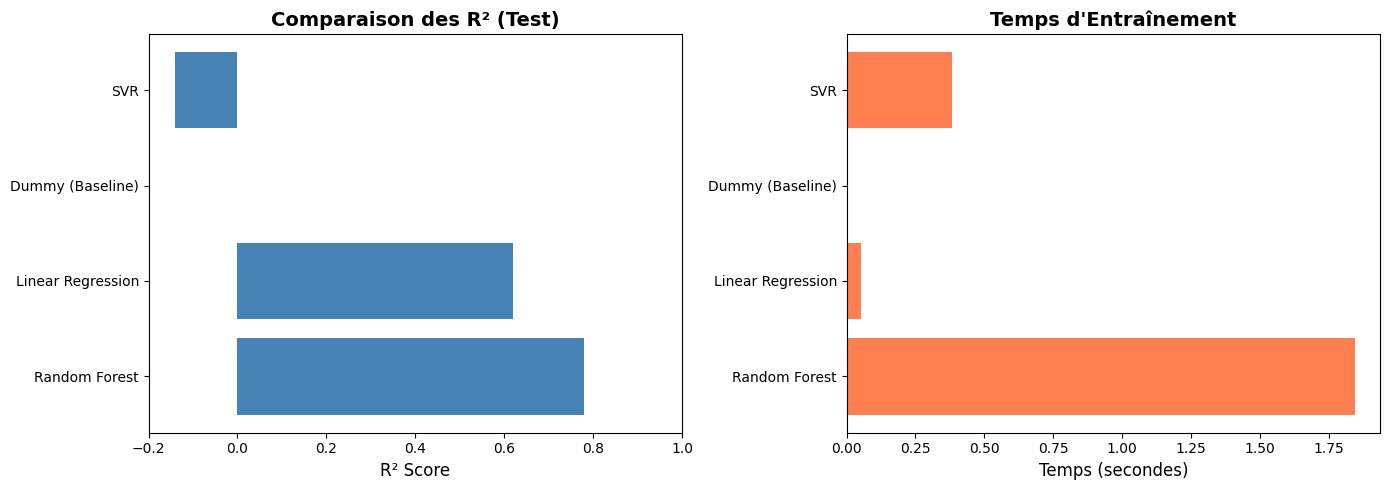

In [25]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
axes[0].barh(resultats_df['Modèle'], resultats_df['R² Test'], color='steelblue')
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Comparaison des R² (Test)', fontsize=14, fontweight='bold')
axes[0].set_xlim(-0.2, 1.0)

# Temps d'entraînement
axes[1].barh(resultats_df['Modèle'], resultats_df['Temps (s)'], color='coral')
axes[1].set_xlabel('Temps (secondes)', fontsize=12)
axes[1].set_title('Temps d\'Entraînement', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Visualisation de la Prédiction

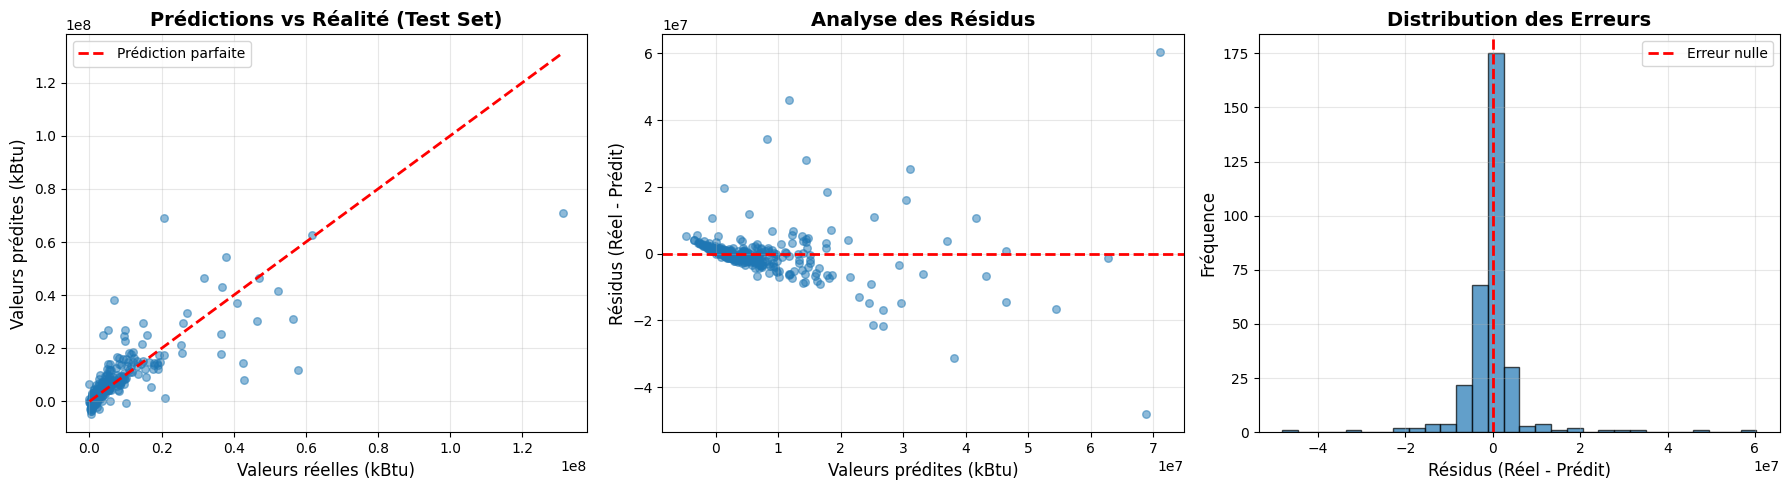

In [26]:
# Récupérer le modèle Linear Regression entraîné
lr_model = modeles['Linear Regression']

# Faire les prédictions (si pas déjà fait)
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

# Créer une figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================================
# 1️⃣ GRAPHIQUE 1 : Valeurs réelles vs Prédictions (TEST)
# ============================================================
axes[0].scatter(y_test, y_pred_test_lr, alpha=0.5, s=30)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (kBtu)', fontsize=12)
axes[0].set_ylabel('Valeurs prédites (kBtu)', fontsize=12)
axes[0].set_title('Prédictions vs Réalité (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ============================================================
# 2️⃣ GRAPHIQUE 2 : Résidus (erreurs de prédiction)
# ============================================================
residus = y_test - y_pred_test_lr
axes[1].scatter(y_pred_test_lr, residus, alpha=0.5, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Valeurs prédites (kBtu)', fontsize=12)
axes[1].set_ylabel('Résidus (Réel - Prédit)', fontsize=12)
axes[1].set_title('Analyse des Résidus', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# ============================================================
# 3️⃣ GRAPHIQUE 3 : Distribution des erreurs
# ============================================================
axes[2].hist(residus, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', lw=2, label='Erreur nulle')
axes[2].set_xlabel('Résidus (Réel - Prédit)', fontsize=12)
axes[2].set_ylabel('Fréquence', fontsize=12)
axes[2].set_title('Distribution des Erreurs', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse**
on voit la plupart des points assez proche de la ligne de prédiction.La prédiction est moyenne. Cela est conforme au R²Test (coef de determination) qui est moyen (54%). Le modèle a du mal a faire une meilleure prediction à cause des valeurs extremes des données, pour SiteEnergieUse,la valeur min est de zéro, et la valeur maximum est de  4.483853e+08. On a vu que certains batiment comme les écoles, les hopitaux ont des valeurs de consommation d'energie très éloignées. Pour avoir une meilleure prediction, il faudrait plus de variable pour mieux entrainer le modèle.

## 12. Conclusions et Recommandations

### Synthèse des Résultats

**Modèle recommandé** : Linear Regression avec un Dataframe: 1621

**Performances** :
- R² Test ~ 0.62 , le modèle explique 62% de la variance de la consommation énergétique
- R² Train ~ 0.84 , prédiction du supérieur sur le Train
- Très rapide à entraîner (<0.1s)

### 37 Features clés utilisées
**Surface** : PropertyGFATotal, PropertyGFABuilding(s), LargestPropertyUseTypeGFA
**Structure** : NumberofFloors, NumberofBuildings
**Features engineerées** : parking_ratio, main_use_ratio, usable_area, building_age, second_use_ratio, third_use_ratio
**Localisation** : Latitude, Longitude, variables Neighborhood encodées
**Type de bâtiment** : variables BuildingType et PrimaryPropertyType encodées
**Certification** : ENERGYSTARScore

### Recommandations pour la Ville de Seattle

1. **Cibler les grands bâtiments** : La taille est le facteur principal de consommation
2. **Apporter de l'homogeneité au dataset**:  recolter plus de données pour avoir une meilleure prediction
3. **Apporter une analyse specifique sur les individus "Other/Autres"** : les hopitaux, tribunaux et Data Center ont une consommation anormale d'energie. Une comparaison avec des batiments similaire dans des régions aux climats similaires apporterait une meilleure prediction. 
